### Task 5 (`flights.csv`)

**Name:** Ali Afzal
**Roll No.:** SU92-BSAIM-F23-102
**Subject:** Data Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")

# House style copied from the Week 1 lecture: colour-blind-safe palette,
# left-aligned titles, no chart box, light grid.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "lines.linewidth": 2, "font.size": 11,
})


def note(ax, text, y=-0.2):
    # Grey footnote under a chart - used to say which rows were left out.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

In [2]:
df = pd.read_csv(DATA / "flights.csv")
print(df.shape, "- missing values:", df.isna().sum().sum())
df.head(3)

(144, 3) - missing values: 0


,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132


144 rows, 12 years x 12 months, nothing missing. The numbers are monthly totals of international airline
passengers, in thousands.

### 1. Building a proper time axis

`year` is a number and `month` is text like `"January"`. If I just glue them together as text and sort, the
months come out in alphabetical order (April, August, December...), and matplotlib would treat each label as a
separate category with no real spacing. So I turn them into a real date. `%B` is the format code for a full
month name, so `"1949-January"` becomes 1 January 1949. Then I sort by that date.

In [3]:
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"], format="%Y-%B")
df = df.sort_values("date").reset_index(drop=True)
months = list(df["month"].unique())   # January ... December, in calendar order
df[["date", "year", "month", "passengers"]].head()

,date,year,month,passengers
0,1949-01-01,1949,January,112
1,1949-02-01,1949,February,118
2,1949-03-01,1949,March,132
3,1949-04-01,1949,April,129
4,1949-05-01,1949,May,121


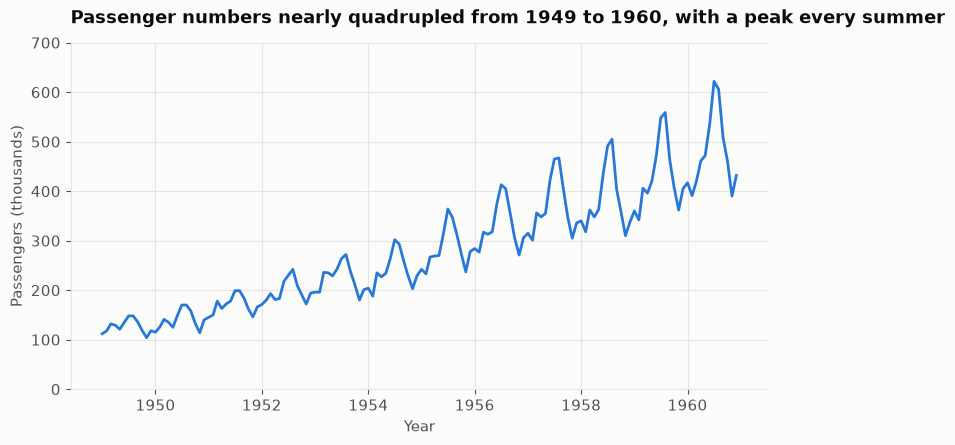

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["date"], df["passengers"], color=BLUE)
ax.set_ylim(0, 700)
ax.set_title("Passenger numbers nearly quadrupled from 1949 to 1960, with a peak every summer")
ax.set_xlabel("Year")
ax.set_ylabel("Passengers (thousands)")
plt.show()

**Why this chart:** one measure over time, 144 points in order, so a single line. The line tells the reader to
read the points in order, and it shows the trend and the repeating pattern together. I started the y-axis at
zero so the growth looks as big as it really is (1,520 thousand passengers in 1949 against 5,714 thousand in 1960).

### 2. Isolating the seasonal cycle

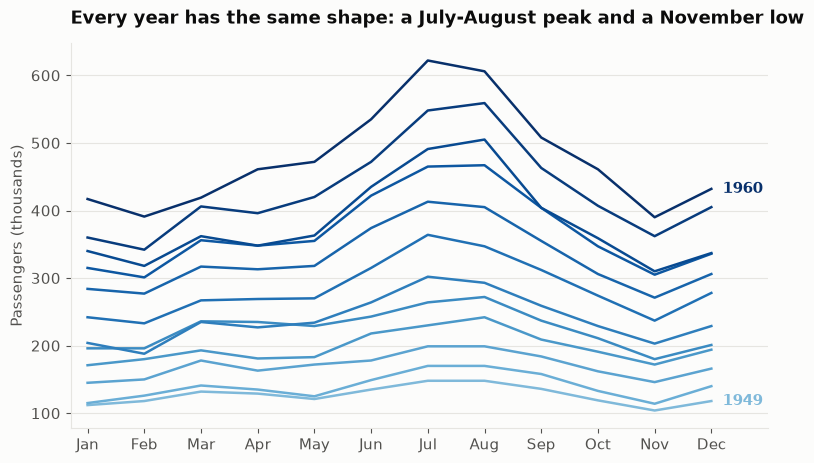

In [5]:
wide = df.pivot(index="month", columns="year", values="passengers").loc[months]
shades = plt.cm.Blues(np.linspace(0.45, 1, wide.shape[1]))   # light = early years, dark = late

fig, ax = plt.subplots(figsize=(9, 5))
for shade, year in zip(shades, wide.columns):
    ax.plot(range(12), wide[year], color=shade, linewidth=1.8)
for year, shade in ((1949, shades[0]), (1960, shades[-1])):
    ax.text(11.2, wide.loc["December", year], str(year), va="center", color=shade, fontweight="bold")

ax.set_xticks(range(12), [m[:3] for m in months])
ax.set_xlim(-0.3, 12)
ax.set_title("Every year has the same shape: a July-August peak and a November low")
ax.set_ylabel("Passengers (thousands)")
ax.xaxis.grid(False)
plt.show()

**Why this chart:** putting months on the x-axis and drawing one line per year takes the long-term growth out
of the picture (it just stacks the lines on top of each other), so what is left is the shape of a single year.
It is still a line chart because months are ordered. Colour means time here: one blue getting darker from 1949 to
1960, instead of 12 random colours. So I don't need a 12-entry legend, and I only label the first and last years.

Every line has the same shape: flat-ish in spring, climbing through June to a peak in July/August, then a drop to
the lowest point in November, and a small bump in December.

### 3. Which month is consistently busiest?

Raw passenger numbers can't answer this fairly, because every month of 1960 beats every month of 1949. So I
compare each month to **its own year's average**. 100% means a normal month for that year.

In [6]:
df["pct_of_year"] = df["passengers"] / df.groupby("year")["passengers"].transform("mean") * 100
share = df.pivot(index="year", columns="month", values="pct_of_year")[months]

print("Busiest month in each year:")
print(share.idxmax(axis=1).value_counts())

Busiest month in each year:
July      7
August    5
Name: count, dtype: int64


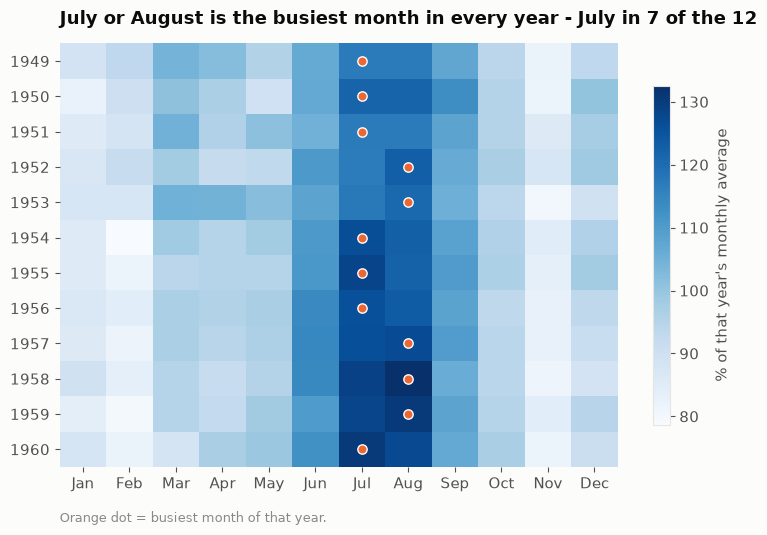

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(share, cmap="Blues", aspect="auto")
busiest = share.values.argmax(axis=1)
ax.scatter(busiest, range(len(share)), marker="o", s=45, color=ORANGE, edgecolor="white")

ax.set_xticks(range(12), [m[:3] for m in months])
ax.set_yticks(range(len(share)), share.index)
ax.grid(False)
ax.spines[["left", "bottom"]].set_visible(False)
fig.colorbar(im, ax=ax, label="% of that year's monthly average", shrink=0.8)
ax.set_title("July or August is the busiest month in every year - July in 7 of the 12")
note(ax, "Orange dot = busiest month of that year.", y=-0.13)
plt.show()

**Why this chart:** the question has the word *consistently* in it, so I need to see every year separately, not one
average. A heatmap with one row per year and one column per month does that. The two dark columns in July and
August run straight down the whole chart, so you can see the answer at a glance, and the orange dot marks the
single busiest month of each year. Using "% of the year's average" makes the rows comparable, so 1949 and 1960 get
the same colour scale.

**Answer:** it is July, but only just. July was the busiest month in 7 of the 12 years and August in the other 5.
Both are about 24% above a normal month. November is the quietest month (about 17% below normal). I first
tried a bar chart of the average for each month, but July and August came out almost exactly equal (23.6% vs
23.7%), which made August look like the winner even though July wins more years. The heatmap shows both facts.

### 4. Which chart would I put in a report?

I would put **chart 1 (the single line)** in a report. It is the only one of the three a general reader can
understand without explanation, and it shows the most important fact (the airline nearly quadrupled) while still
showing the summer peaks.

The other two don't belong in the *same* report because they answer narrower questions that come out of chart 1.
Chart 2 is an analyst's chart: twelve overlapping lines are fine for me while I'm exploring, but a report reader
would have to work to decode it. Chart 3 answers one specific planning question ("which month is busiest?"). Its
answer fits in a sentence under chart 1 ("traffic peaks in July and August, about 24% above an average month").
If I added all three, the report would be showing the same pattern three times in three different ways. That
goes against "one chart, one message", this time across a whole report.

### Is the seasonality growing, or just the airline?

The swing between the quietest and busiest month grows from 44 thousand passengers in 1949 to 232 thousand in
1960, so in absolute numbers it gets more than 5 times bigger. But the airline itself almost quadrupled. If the
seasonal pattern is a fixed *percentage* of the traffic, the swing will grow automatically as traffic grows,
without the seasonality itself changing.

The chart that settles it is **the same line chart on a log y-axis**. On a log scale equal *percentage*
changes take up equal heights. So if the summer wiggles stay the same height, the seasonality is just scaling
with the airline. If they get taller, the seasonality really is growing.

In [8]:
swing = df.groupby("year")["passengers"].agg(["min", "max", "mean"])
swing["swing (thousands)"] = swing["max"] - swing["min"]
swing["peak vs yearly average"] = (swing["max"] / swing["mean"]).round(2)
swing[["swing (thousands)", "peak vs yearly average"]].T

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
swing (thousands),44.00,56.00,54.00,71.00,92.00,114.00,131.00,142.00,166.00,195.00,217.00,232.00
peak vs yearly average,1.17,1.22,1.17,1.23,1.21,1.26,1.28,1.26,1.27,1.33,1.31,1.31


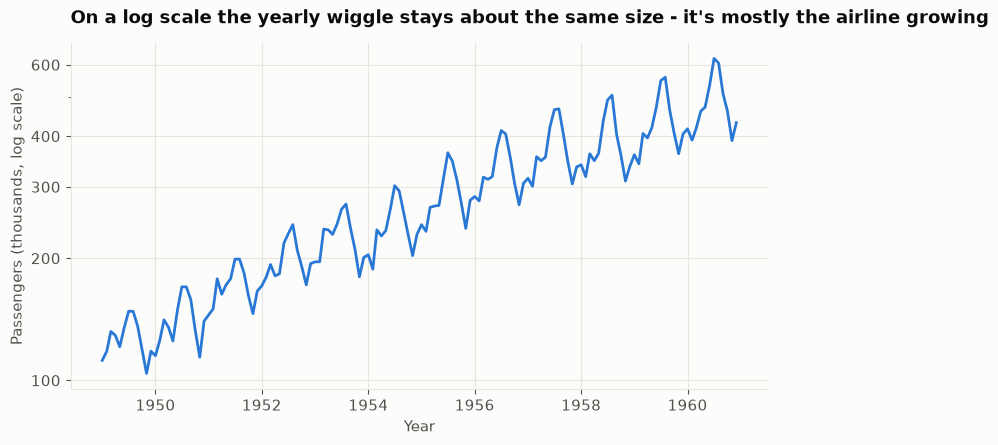

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["date"], df["passengers"], color=BLUE)
ax.set_yscale("log")
ax.set_yticks([100, 200, 300, 400, 600])
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}")
ax.yaxis.set_minor_formatter(lambda v, p: "")
ax.set_title("On a log scale the yearly wiggle stays about the same size - it's mostly the airline growing")
ax.set_xlabel("Year")
ax.set_ylabel("Passengers (thousands, log scale)")
plt.show()

On the log scale the wiggles are roughly the same height from start to end, so **most of the growing swing is
just the airline growing**. The seasonal pattern is a percentage of the traffic, and it looks bigger because
the traffic got bigger.

It is not *completely* constant, though. The table shows the peak month went from 17% above the yearly average
in 1949 to about 31% above it in 1960, so the summer peak did get a bit sharper in relative terms, maybe
because more people were flying for holidays. But that change is small compared with the 5× growth in the raw
swing. (A "% of that year's average" chart like the heatmap in part 3 would show the same thing in a different way.)